In [1]:

"""
Load and visualize pain scores for all participants from individual session CSVs
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style
sns.set_theme(style="white")

# %%
# Configuration
BIDS_DIR = Path('/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB')

# %%
# Find all pain score CSV files
print("Searching for pain score files...")
pain_files = list(BIDS_DIR.glob('sub-*/ses-*/ehr/*_pain-scores.csv'))
print(f"Found {len(pain_files)} pain score files")

# %%
# Load all pain data — fixed datetime parsing
all_pain_data = []
for file in pain_files:
    df = pd.read_csv(file)
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')
    df['session_start'] = pd.to_datetime(df['session_start'], format='%Y-%m-%d %H:%M:%S')
    df['session_end'] = pd.to_datetime(df['session_end'], format='%Y-%m-%d %H:%M:%S')
    all_pain_data.append(df)

pain_df = pd.concat(all_pain_data, ignore_index=True)

# Combine all data
pain_df = pd.concat(all_pain_data, ignore_index=True)

print(f"\nLoaded {len(pain_df)} total pain measurements")
print(f"Participants: {pain_df['sub_id'].nunique()}")
print(f"Sessions: {len(pain_df.groupby(['sub_id', 'ses_id']))}")

pain_df


Searching for pain score files...
Found 99 pain score files

Loaded 4849 total pain measurements
Participants: 97
Sessions: 99


,sub_id,ses_id,date,max_pain,session_start,session_end
0,sub-231,ses-01,2000-01-01 15:52:00,2.0,2000-01-01 15:33:47,2000-01-15 14:17:18
1,sub-231,ses-01,2000-01-01 18:15:00,4.0,2000-01-01 15:33:47,2000-01-15 14:17:18
2,sub-231,ses-01,2000-01-01 19:15:00,4.0,2000-01-01 15:33:47,2000-01-15 14:17:18
3,sub-231,ses-01,2000-01-01 20:00:00,4.0,2000-01-01 15:33:47,2000-01-15 14:17:18
4,sub-231,ses-01,2000-01-01 21:18:00,3.0,2000-01-01 15:33:47,2000-01-15 14:17:18
...,...,...,...,...,...,...
4844,sub-256,ses-01,2000-01-11 11:00:00,7.0,2000-01-01 20:30:14,2000-01-11 16:21:18
4845,sub-256,ses-01,2000-01-11 11:12:00,7.0,2000-01-01 20:30:14,2000-01-11 16:21:18
4846,sub-256,ses-01,2000-01-11 12:04:00,7.0,2000-01-01 20:30:14,2000-01-11 16:21:18
4847,sub-256,ses-01,2000-01-11 14:50:00,8.0,2000-01-01 20:30:14,2000-01-11 16:21:18


NameError: name 'rng' is not defined

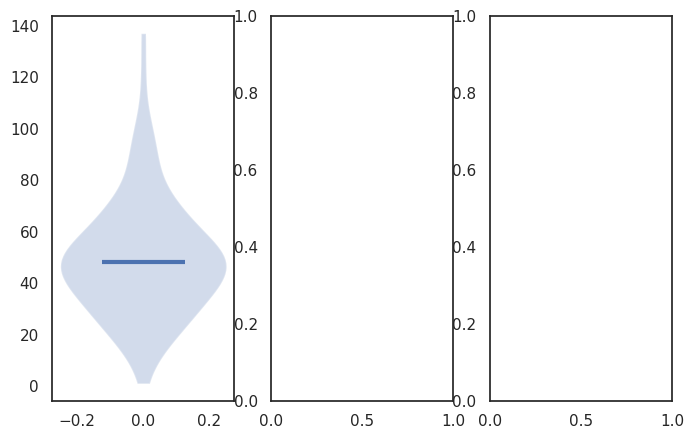

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 16})  # base size for everything

patient_stats = pain_df.groupby('sub_id').agg(
    n_scores=('max_pain', 'count'),
    mean_score=('max_pain', 'mean'),
    score_range=('max_pain', lambda x: x.max() - x.min())
).reset_index()

metrics = [
    ('n_scores',    'assessments per patient'),
    ('mean_score',  'mean pain score'),
    ('score_range', 'pain score range'),
]

fig, axes = plt.subplots(1, 3, figsize=(8, 5))

for ax, (col, label) in zip(axes, metrics):
    vals = patient_stats[col].values

    parts = ax.violinplot(vals, positions=[0], showmedians=True,
                          showextrema=False)

    for pc in parts['bodies']:
        pc.set_alpha(0.25)
        pc.set_linewidth(1.2)
    parts['cmedians'].set_linewidth(3)

    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(jitter, vals, s=18, alpha=0.7,
               linewidths=0.4, edgecolors='white', zorder=3)

    ax.set_xlim(-0.3, 0.3)
    ax.set_xticks([])
    ax.set_ylabel(label, fontsize=18)       # bumped
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=16)  # bumped

fig.tight_layout()
plt.savefig('pain_distributions.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import seaborn as sns

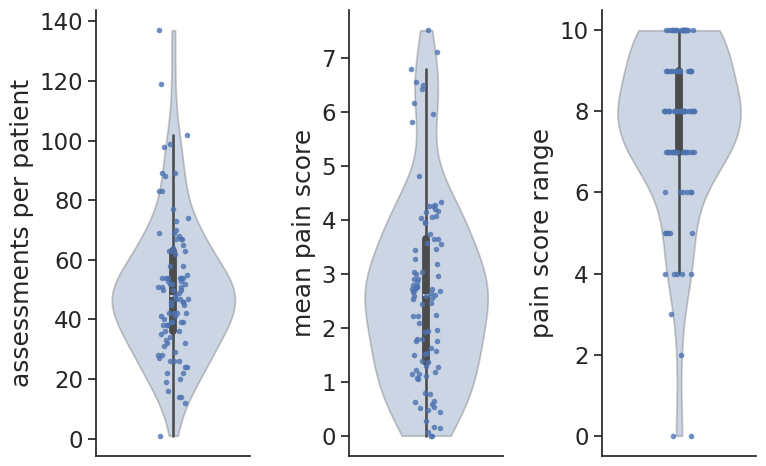

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='white', font_scale=1.5)
sns.set_style("ticks")

patient_stats = pain_df.groupby('sub_id').agg(
    n_scores=('max_pain', 'count'),
    mean_score=('max_pain', 'mean'),
    score_range=('max_pain', lambda x: x.max() - x.min())
).reset_index()

metrics = [
    ('n_scores',    'assessments per patient'),
    ('mean_score',  'mean pain score'),
    ('score_range', 'pain score range'),
]

fig, axes = plt.subplots(1, 3, figsize=(8, 5))

for ax, (col, label) in zip(axes, metrics):
    sns.stripplot(
        y=patient_stats[col], ax=ax,
        size=4,
        alpha=0.8,
        color = 'C0',
        edgecolor='white'
    )
    sns.violinplot(
        y=patient_stats[col], ax=ax,          # we'll draw the median via stripplot overlay
        cut=0,               # don't extend beyond data range
        alpha=0.3,
    )

   

    ax.set_ylabel(label)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_xlim(-0.5, 0.5)
    sns.despine(ax=ax)
    ax.tick_params(axis='y')

fig.tight_layout()
plt.savefig('pain_distributions.png', bbox_inches='tight')
plt.show()

In [ ]:


fig, ax = plt.subplots(figsize=(8, 3))
sub_data = pain_df[pain_df['sub_id'] == 'sub-259'].sort_values('date').copy()
t0 = sub_data['session_start'].iloc[0]
sub_data['hours'] = (sub_data['date'] - t0).dt.total_seconds() / 3600

sns.lineplot(
    data=sub_data, x='hours', y='max_pain',
    ax=ax, linewidth=3, alpha=0.6, color='C0'
)
sns.scatterplot(
    data=sub_data, x='hours', y='max_pain',
    ax=ax, s=60, color='#3B4A6B', alpha=0.9, edgecolor='white', linewidth=0.4
)

ax.set_ylim(-.5, 10.5)
ax.set_xlabel('hours since admission')
ax.set_ylabel('pain score')
sns.despine(ax=ax)

fig.tight_layout()
plt.savefig('sub259_pain_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()







IndexError: single positional indexer is out-of-bounds

ValueError: Could not interpret value `max_pain` for `y`. An entry with this name does not appear in `data`.

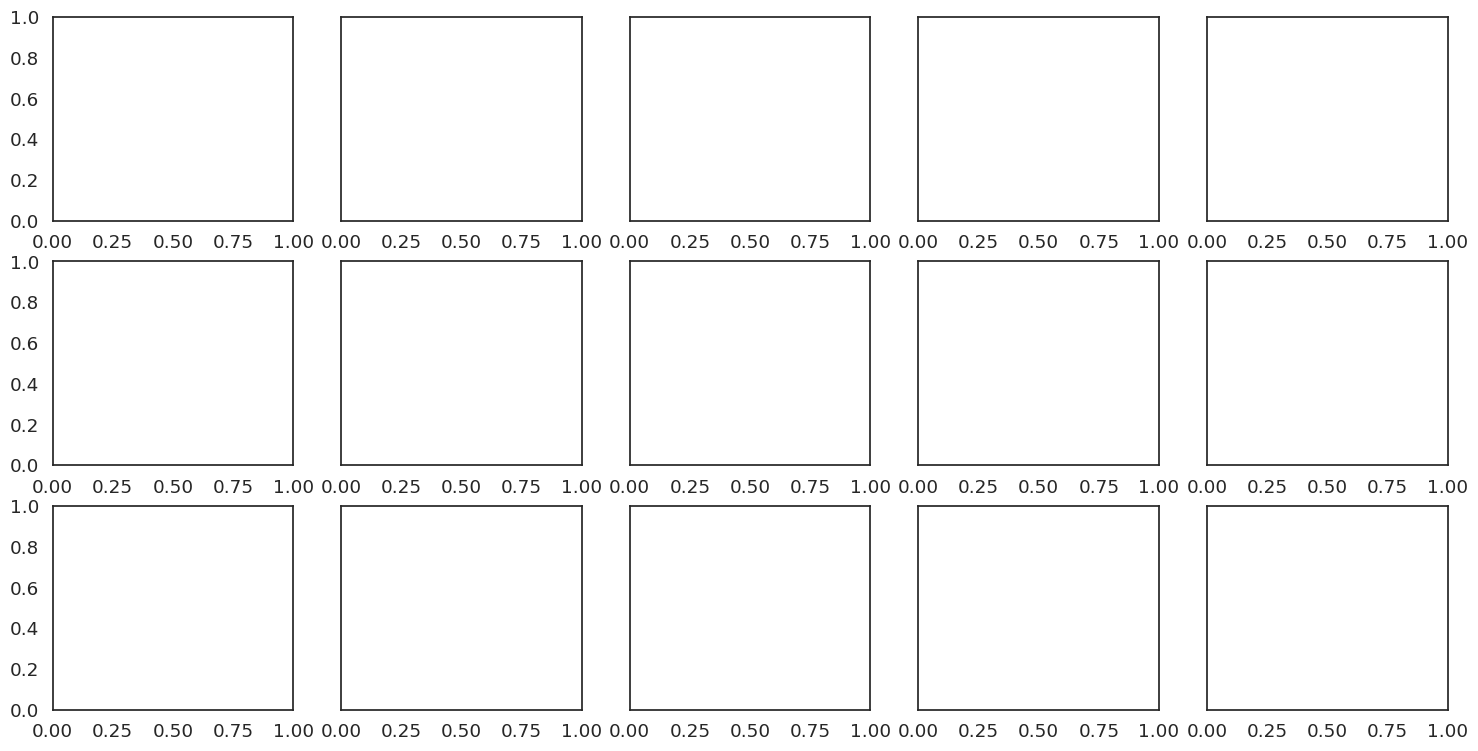

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='white', font_scale=1.2)

# Sample 15 random subjects
rng = np.random.default_rng(54)
sample_subs = rng.choice(pain_df['sub_id'].unique(), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharey=True)

for ax, sub in zip(axes.flat, sample_subs):
    sub_data = pain_df[pain_df['sub_id'] == sub].sort_values('date')
    
    # Normalize time to hours since session start
    t0 = sub_data['session_start'].iloc[0]
    sub_data = sub_data.copy()
    sub_data['hours'] = (sub_data['date'] - t0).dt.total_seconds() / 3600

    sns.lineplot(
        data=sub_data, x='hours', y='max_pain',
        ax=ax, linewidth=1.2, alpha=0.6, color='steelblue'
    )
    sns.scatterplot(
        data=sub_data, x='hours', y='max_pain',
        ax=ax, s=20, color='#3B4A6B', alpha=0.8, edgecolor='white', linewidth=0.3
    )

    ax.set_title(sub, fontsize=11)
    ax.set_xlabel('hours since admission', fontsize=10)
    ax.set_ylabel('pain score' if ax in axes[:, 0] else '', fontsize=10)
    ax.set_ylim(0, 10.5)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)

fig.suptitle('Pain scores over time — 15 random patients', fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig('pain_trajectories_sample.pdf', bbox_inches='tight')
plt.show()

In [ ]:

"""
Load and visualize med admins  for all participants from individual session CSVs
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style
sns.set_theme(style="white")

# %%
# Configuration
BIDS_DIR = Path('/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB')

# %%
# Find all med admin CSV files
print("Searching for med admin files...")
pain_files = list(BIDS_DIR.glob('sub-*/ses-*/ehr/*_med-admin.csv'))
print(f"Found {len(pain_files)} pain score files")

# %%
# Load all pain data — fixed datetime parsing
all_pain_data = []
for file in pain_files:
    df = pd.read_csv(file)
    df['date'] = pd.to_datetime(df['taken_date'], format='%Y-%m-%d %H:%M:%S')
    df['session_start'] = pd.to_datetime(df['session_start'], format='%Y-%m-%d %H:%M:%S')
    df['session_end'] = pd.to_datetime(df['session_end'], format='%Y-%m-%d %H:%M:%S')
    all_pain_data.append(df)

med_admin_df = pd.concat(all_pain_data, ignore_index=True)

# Combine all data
pain_df = pd.concat(all_pain_data, ignore_index=True)

print(f"\nLoaded {len(pain_df)} total med measurements")
print(f"Participants: {pain_df['sub_id'].nunique()}")
print(f"Sessions: {len(pain_df.groupby(['sub_id', 'ses_id']))}")

med_admin_df


Searching for med admin files...
Found 98 pain score files

Loaded 7340 total pain measurements
Participants: 96
Sessions: 98


,sub_id,ses_id,taken_date,session_start,session_end,medication,line,mar_action,sig,route,site,infusion_rate,infusion_rate_unit,dose_unit,mar_duration,mar_duration_unit,date
0,sub-231,ses-01,2000-01-01 18:13:00,2000-01-01 15:33:47,2000-01-15 14:17:18,POLYETHYLENE GLYCOL 3350 17 GRAM PO PWPK,1,Given,17.0,Oral,NaN,NaN,NaN,g,NaN,NaN,2000-01-01 18:13:00
1,sub-231,ses-01,2000-01-01 18:14:00,2000-01-01 15:33:47,2000-01-15 14:17:18,SENNOSIDES 8.6 MG PO TABS,1,Given,1.0,Oral,NaN,NaN,NaN,tablet,NaN,NaN,2000-01-01 18:14:00
2,sub-231,ses-01,2000-01-01 18:15:00,2000-01-01 15:33:47,2000-01-15 14:17:18,ACETAMINOPHEN 325 MG PO TABS,1,Given,650.0,Oral,NaN,NaN,NaN,mg,NaN,NaN,2000-01-01 18:15:00
3,sub-231,ses-01,2000-01-01 18:15:00,2000-01-01 15:33:47,2000-01-15 14:17:18,OXYCODONE 5 MG PO TABS,2,Given,10.0,Oral,NaN,NaN,NaN,mg,NaN,NaN,2000-01-01 18:15:00
4,sub-231,ses-01,2000-01-01 21:17:00,2000-01-01 15:33:47,2000-01-15 14:17:18,DIVALPROEX 500 MG PO TB24,1,Given,1500.0,Oral,NaN,NaN,NaN,mg,NaN,NaN,2000-01-01 21:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7335,sub-256,ses-01,2000-01-11 12:09:00,2000-01-01 20:30:14,2000-01-11 16:21:18,ZONISAMIDE 100 MG PO CAPS,1,Given,300.0,Oral,NaN,NaN,NaN,mg,NaN,NaN,2000-01-11 12:09:00
7336,sub-256,ses-01,2000-01-11 14:50:00,2000-01-01 20:30:14,2000-01-11 16:21:18,ACETAMINOPHEN 325 MG PO TABS,29,Given,650.0,Oral,NaN,NaN,NaN,mg,NaN,NaN,2000-01-11 14:50:00
7337,sub-256,ses-01,2000-01-11 16:02:00,2000-01-01 20:30:14,2000-01-11 16:21:18,MIDAZOLAM 5 MG/ML INJ SOLN,1,Given,5.0,Intravenous,NaN,NaN,NaN,mg,NaN,NaN,2000-01-11 16:02:00
7338,sub-256,ses-01,2000-01-11 16:02:00,2000-01-01 20:30:14,2000-01-11 16:21:18,FENTANYL CITRATE (PF) 50 MCG/ML INJ SOLN (WRAP...,1,Given,50.0,Intravenous,NaN,NaN,NaN,mcg,NaN,NaN,2000-01-11 16:02:00


In [ ]:
len(med_admin_df["medication"].unique())

295

In [41]:
medication_type_map = {
    # Opioids
    'OXYCODONE 5 MG PO TABS': 'opioid',
    'OXYCODONE 15 MG PO TABS': 'opioid',
    'OXYCODONE 5 MG/5 ML PO SOLN': 'opioid',
    'HYDROMORPHONE 1 MG/ML INJ SYRG': 'opioid',
    'HYDROMORPHONE 2 MG PO TABS': 'opioid',
    'HYDROMORPHONE 4 MG PO TABS': 'opioid',
    'FENTANYL (PF) 50 MCG/ML INJECTION': 'opioid',
    'FENTANYL CITRATE (PF) 50 MCG/ML INJ SOLN (WRAPPER RECORD)': 'opioid',
    'FENTANYL CITRATE (PF) 50 MCG/ML INJ SOLN': 'opioid',
    'FENTANYL 100 MCG/2 ML (SHC PHARMACY-COMPOUNDED SYR)': 'opioid',
    'MORPHINE INJECTABLE SYRINGE': 'opioid',
    'MORPHINE 2 MG/ML INJ SYRG': 'opioid',
    'TRAMADOL 50 MG PO TABS': 'opioid',
    'HYDROCODONE-ACETAMINOPHEN 10-325 MG PO TABS': 'opioid',
    'HYDROCODONE-ACETAMINOPHEN 5-325 MG PO TABS': 'opioid',
    'HYDROCODONE-ACETAMINOPHEN 5-500 MG PO TABS': 'opioid',
    'OXYCODONE-ACETAMINOPHEN 5-325 MG PO TABS': 'opioid',
    'ACETAMINOPHEN-CODEINE 300-30 MG PO TABS': 'opioid',
    'BUPRENORPHINE-NALOXONE 2-0.5 MG SL FILM': 'opioid',

    # Non-opioid analgesics
    'ACETAMINOPHEN 325 MG PO TABS': 'non_opioid_analgesic',
    'ACETAMINOPHEN 500 MG PO TABS': 'non_opioid_analgesic',
    'ACETAMINOPHEN 1,000 MG/100 ML (10 MG/ML) IV SOLN': 'non_opioid_analgesic',
    'IBUPROFEN 400 MG PO TABS': 'non_opioid_analgesic',
    'KETOROLAC 30 MG/ML (1 ML) INJ SOLN': 'non_opioid_analgesic',
    'KETOROLAC 15 MG/ML INJ SOLN': 'non_opioid_analgesic',

    # Antiepileptics
    'DIVALPROEX 500 MG PO TB24': 'antiepileptic',
    'DIVALPROEX 250 MG PO TB24': 'antiepileptic',
    'DIVALPROEX 500 MG PO TBEC': 'antiepileptic',
    'DIVALPROEX 250 MG PO TBEC': 'antiepileptic',
    'VALPROIC ACID 250 MG PO CAPS': 'antiepileptic',
    'LAMOTRIGINE 25 MG PO TABS': 'antiepileptic',
    'LAMOTRIGINE 100 MG PO TABS': 'antiepileptic',
    'LAMOTRIGINE 200 MG PO TR24': 'antiepileptic',
    'LAMOTRIGINE 300 MG PO TR24': 'antiepileptic',
    'LAMOTRIGINE 250 MG PO TR24': 'antiepileptic',
    'LAMOTRIGINE 100 MG PO TR24': 'antiepileptic',
    'LAMOTRIGINE 50 MG PO TR24': 'antiepileptic',
    'LEVETIRACETAM 250 MG PO TABS': 'antiepileptic',
    'LEVETIRACETAM 500 MG PO TABS': 'antiepileptic',
    'LEVETIRACETAM 750 MG PO TABS': 'antiepileptic',
    'LEVETIRACETAM 500 MG/5 ML IV SOLN': 'antiepileptic',
    'LEVETIRACETAM IN NACL (ISO-OS) 1,000 MG/100 ML IV PGBK': 'antiepileptic',
    'LEVETIRACETAM IVPB': 'antiepileptic',
    'LEVETIRACETAM IVPB (>1500 MG, <3750 MG)': 'antiepileptic',
    'LEVETIRACETAM 500 MG PO TB24': 'antiepileptic',
    'LEVETIRACETAM 750 MG PO TB24': 'antiepileptic',
    'LEVETIRACETAM 500 MG/5 ML (5 ML) PO SOLN': 'antiepileptic',
    'LACOSAMIDE 50 MG PO TABS': 'antiepileptic',
    'LACOSAMIDE 100 MG PO TABS': 'antiepileptic',
    'LACOSAMIDE 150 MG PO TABS': 'antiepileptic',
    'LACOSAMIDE 200 MG PO TABS': 'antiepileptic',
    'LACOSAMIDE 200 MG/20 ML IV SOLN': 'antiepileptic',
    'LACOSAMIDE IVPB': 'antiepileptic',
    'BRIVARACETAM 25 MG PO TABS': 'antiepileptic',
    'BRIVARACETAM 50 MG PO TABS': 'antiepileptic',
    'BRIVARACETAM 100 MG PO TABS': 'antiepileptic',
    'BRIVARACETAM 50 MG/5 ML IV SOLN': 'antiepileptic',
    'CARBAMAZEPINE 100 MG PO TB12': 'antiepileptic',
    'CARBAMAZEPINE 200 MG PO TB12': 'antiepileptic',
    'CARBAMAZEPINE 400 MG PO TB12': 'antiepileptic',
    'CARBAMAZEPINE 200 MG PO TABS': 'antiepileptic',
    'CARBAMAZEPINE 100 MG PO CHEW': 'antiepileptic',
    'OXCARBAZEPINE 150 MG PO TABS': 'antiepileptic',
    'OXCARBAZEPINE 300 MG PO TABS': 'antiepileptic',
    'OXCARBAZEPINE 600 MG PO TABS': 'antiepileptic',
    'OXCARBAZEPINE 300 MG PO TB24': 'antiepileptic',
    'ESLICARBAZEPINE 200 MG PO TABS': 'antiepileptic',
    'ESLICARBAZEPINE 600 MG PO TABS': 'antiepileptic',
    'ESLICARBAZEPINE 800 MG PO TABS': 'antiepileptic',
    'PHENYTOIN SODIUM EXTENDED 30 MG PO CAPS': 'antiepileptic',
    'PHENYTOIN SODIUM EXTENDED 100 MG PO CAPS': 'antiepileptic',
    'PHENYTOIN IVPB (>1000 MG)': 'antiepileptic',
    'PHENOBARBITAL 30 MG PO TABS': 'antiepileptic',
    'PHENOBARBITAL 60 MG PO TABS': 'antiepileptic',
    'PHENOBARBITAL 100 MG PO TABS': 'antiepileptic',
    'TOPIRAMATE 25 MG PO TABS': 'antiepileptic',
    'TOPIRAMATE 50 MG PO CP24': 'antiepileptic',
    'TOPIRAMATE 100 MG PO TABS': 'antiepileptic',
    'TOPIRAMATE 200 MG PO TABS': 'antiepileptic',
    'ZONISAMIDE 25 MG PO CAPS': 'antiepileptic',
    'ZONISAMIDE 100 MG PO CAPS': 'antiepileptic',
    'GABAPENTIN 100 MG PO CAPS': 'antiepileptic',
    'GABAPENTIN 300 MG PO CAPS': 'antiepileptic',
    'GABAPENTIN 400 MG PO CAPS': 'antiepileptic',
    'GABAPENTIN 600 MG PO TABS': 'antiepileptic',
    'GABAPENTIN 800 MG PO TABS': 'antiepileptic',
    'PREGABALIN 50 MG PO CAPS': 'antiepileptic',
    'PREGABALIN 75 MG PO CAPS': 'antiepileptic',
    'PREGABALIN 100 MG PO CAPS': 'antiepileptic',
    'PREGABALIN 150 MG PO CAPS': 'antiepileptic',
    'PERAMPANEL 2 MG PO TABS': 'antiepileptic',
    'PERAMPANEL 12 MG PO TABS': 'antiepileptic',
    'CLOBAZAM 2.5 MG/ML PO SUSP': 'antiepileptic',
    'CLOBAZAM 10 MG PO TABS': 'antiepileptic',
    'CLOBAZAM 20 MG PO TABS': 'antiepileptic',
    'CENOBAMATE 50 MG PO TABS': 'antiepileptic',
    'CENOBAMATE 100 MG PO TABS': 'antiepileptic',
    'CENOBAMATE 200 MG PO TABS': 'antiepileptic',
    'RUFINAMIDE 400 MG PO TABS': 'antiepileptic',
    'FELBAMATE 400 MG PO TABS': 'antiepileptic',
    'CANNABIDIOL 100 MG/ML PO SOLN': 'antiepileptic',  # FDA-approved Epidiolex
    'CLORAZEPATE DIPOTASSIUM 3.75 MG PO TABS': 'antiepileptic',  # used as AED
    'BUTALBITAL-ACETAMINOPHEN-CAFF 50-325-40 MG PO TABS': 'antiepileptic',

    # Benzodiazepines
    'LORAZEPAM 0.5 MG PO TABS': 'benzodiazepine',
    'LORAZEPAM 1 MG PO TABS': 'benzodiazepine',
    'LORAZEPAM 2 MG/ML INJ SOLN': 'benzodiazepine',
    'LORAZEPAM 2 MG/ML INJ (EPILEPSY ORDER SET)': 'benzodiazepine',
    'CLONAZEPAM 0.25 MG PO TBDL': 'benzodiazepine',
    'CLONAZEPAM 0.5 MG PO TABS': 'benzodiazepine',
    'CLONAZEPAM 1 MG PO TABS': 'benzodiazepine',
    'CLONAZEPAM 1 MG PO TBDL': 'benzodiazepine',
    'DIAZEPAM 5 MG/ML INJ SYRG': 'benzodiazepine',
    'MIDAZOLAM 1 MG/ML INJ SOLN': 'benzodiazepine',
    'MIDAZOLAM (PF) 5 MG/ML INJ SOLN': 'benzodiazepine',
    'MIDAZOLAM 5 MG/ML INJ SOLN': 'benzodiazepine',
    'ALPRAZOLAM 0.25 MG PO TABS': 'benzodiazepine',

    # Sedatives / hypnotics
    'MELATONIN 3 MG PO TABS': 'sedative_hypnotic',
    'MELATONIN 3 MG PO TBDL': 'sedative_hypnotic',
    'MELATONIN 5 MG PO TABS': 'sedative_hypnotic',
    'RAMELTEON 8 MG PO TABS': 'sedative_hypnotic',
    'DARIDOREXANT 25 MG PO TABS': 'sedative_hypnotic',
    'DARIDOREXANT 50 MG PO TABS': 'sedative_hypnotic',
    'DIPHENHYDRAMINE HCL 25 MG PO CAPS': 'sedative_hypnotic',
    'DIPHENHYDRAMINE HCL 50 MG PO CAPS': 'sedative_hypnotic',
    'HYDROXYZINE HCL 25 MG PO TABS': 'sedative_hypnotic',
    'TRAZODONE 50 MG PO TABS': 'sedative_hypnotic',
    'MIRTAZAPINE 15 MG PO TABS': 'sedative_hypnotic',
    'PROPOFOL 10 MG/ML IV INJECTION': 'sedative_hypnotic',

    # Antidepressants
    'ESCITALOPRAM 10 MG PO TABS': 'antidepressant',
    'ESCITALOPRAM OXALATE 10 MG PO TABS': 'antidepressant',
    'SERTRALINE 25 MG PO TABS': 'antidepressant',
    'SERTRALINE 50 MG PO TABS': 'antidepressant',
    'SERTRALINE 100 MG PO TABS': 'antidepressant',
    'FLUOXETINE 20 MG PO CAPS': 'antidepressant',
    'CITALOPRAM 40 MG PO TABS': 'antidepressant',
    'DULOXETINE 20 MG PO CPDR': 'antidepressant',
    'DULOXETINE 30 MG PO CPDR': 'antidepressant',
    'VENLAFAXINE 75 MG PO CP24': 'antidepressant',
    'VENLAFAXINE 150 MG PO CP24': 'antidepressant',
    'BUPROPION HCL 150 MG PO TB24': 'antidepressant',
    'VORTIOXETINE 20 MG PO TABS': 'antidepressant',

    # Antipsychotics
    'QUETIAPINE 100 MG PO TABS': 'antipsychotic',
    'RISPERIDONE 0.5 MG PO TABS': 'antipsychotic',
    'RISPERIDONE 0.5 MG PO TBDL': 'antipsychotic',
    'RISPERIDONE 1 MG PO TABS': 'antipsychotic',
    'RISPERIDONE 1 MG PO TBDL': 'antipsychotic',
    'HALOPERIDOL LACTATE 5 MG/ML INJ SOLN': 'antipsychotic',
    'CHLORPROMAZINE 25 MG PO TABS': 'antipsychotic',
    'ASENAPINE MALEATE 5 MG SL SUBL': 'antipsychotic',

    # Antiemetics
    'ONDANSETRON 4 MG PO TBDL': 'antiemetic',
    'ONDANSETRON HCL (PF) 4 MG/2 ML INJ SOLN': 'antiemetic',
    'GRANISETRON HCL 1 MG/ML (1 ML) IV SOLN': 'antiemetic',
    'GRANISETRON (PF) 1 MG/ML (1 ML) IV SOLN': 'antiemetic',
    'PROCHLORPERAZINE MALEATE 10 MG PO TABS': 'antiemetic',
    'PROCHLORPERAZINE EDISYLATE 10 MG/2 ML (5 MG/ML) INJ SOLN': 'antiemetic',
    'METOCLOPRAMIDE HCL 5 MG/ML INJ SOLN': 'antiemetic',
    'METOCLOPRAMIDE HCL 10 MG PO TABS': 'antiemetic',
    'APREPITANT 40 MG PO CAPS': 'antiemetic',

    # Laxatives / bowel agents
    'POLYETHYLENE GLYCOL 3350 17 GRAM PO PWPK': 'laxative_bowel',
    'SENNOSIDES 8.6 MG PO TABS': 'laxative_bowel',
    'LACTULOSE 20 GRAM/30 ML PO SOLN': 'laxative_bowel',
    'MAGNESIUM CITRATE PO SOLN': 'laxative_bowel',
    'MAGNESIUM HYDROXIDE 400 MG/5 ML PO SUSP': 'laxative_bowel',
    'DOCUSATE SODIUM 100 MG PO CAPS': 'laxative_bowel',
    'DOCUSATE SODIUM 250 MG PO CAPS': 'laxative_bowel',
    'BISACODYL 5 MG PO TBEC': 'laxative_bowel',
    'BISACODYL 10 MG PR SUPP': 'laxative_bowel',

    # Muscle relaxants
    'CYCLOBENZAPRINE 5 MG PO TABS': 'muscle_relaxant',
    'CYCLOBENZAPRINE 10 MG PO TABS': 'muscle_relaxant',
    'CARISOPRODOL 350 MG PO TABS': 'muscle_relaxant',

    # Cardiovascular
    'METOPROLOL TARTRATE 25 MG PO TABS': 'cardiovascular',
    'METOPROLOL TARTRATE 5 MG/5 ML IV SOLN': 'cardiovascular',
    'METOPROLOL SUCCINATE 25 MG PO TB24': 'cardiovascular',
    'METOPROLOL SUCCINATE 50 MG PO TB24': 'cardiovascular',
    'CARVEDILOL 25 MG PO TABS': 'cardiovascular',
    'ATENOLOL 25 MG PO TABS': 'cardiovascular',
    'PROPRANOLOL 10 MG PO TABS': 'cardiovascular',
    'LISINOPRIL 5 MG PO TABS': 'cardiovascular',
    'LISINOPRIL 10 MG PO TABS': 'cardiovascular',
    'LISINOPRIL 40 MG PO TABS': 'cardiovascular',
    'ENALAPRIL MALEATE 10 MG PO TABS': 'cardiovascular',
    'LOSARTAN 50 MG PO TABS': 'cardiovascular',
    'VALSARTAN 320 MG PO TABS': 'cardiovascular',
    'AMLODIPINE 5 MG PO TABS': 'cardiovascular',
    'AMLODIPINE 10 MG PO TABS': 'cardiovascular',
    'HYDRALAZINE 10 MG PO TABS': 'cardiovascular',
    'HYDRALAZINE 20 MG/ML INJ SOLN': 'cardiovascular',
    'HYDRALAZINE 20 MG/ML INJ SOLN (24 HOUR STOP TIME)': 'cardiovascular',
    'FUROSEMIDE 20 MG PO TABS': 'cardiovascular',
    'FUROSEMIDE 40 MG PO TABS': 'cardiovascular',
    'ATORVASTATIN 10 MG PO TABS': 'cardiovascular',
    'ATORVASTATIN 20 MG PO TABS': 'cardiovascular',
    'ATORVASTATIN 40 MG PO TABS': 'cardiovascular',
    'ROSUVASTATIN 10 MG PO TABS': 'cardiovascular',
    'ROSUVASTATIN 20 MG PO TABS': 'cardiovascular',
    'ENOXAPARIN 40 MG/0.4 ML SC SYRG': 'cardiovascular',
    'HEPARIN, PORCINE (PF) 5,000 UNIT/0.5 ML INJ SOLN': 'cardiovascular',
    'EPHEDRINE SULFATE 50 MG/ML IV SOLN': 'cardiovascular',
    'PHENYLEPHRINE HCL 10 MG/ML INJ SOLN': 'cardiovascular',

    # Antibiotics
    'CEFAZOLIN IV PUSH (1 GRAM VIAL ONLY)': 'antibiotic',
    'CEFAZOLIN IV PUSH (1 GRAM VIAL + NS VIAL)': 'antibiotic',
    'CEFAZOLIN IN DEXTROSE (ISO-OS) 1 GRAM/50 ML IV PGBK': 'antibiotic',
    'CEFAZOLIN IN DEXTROSE (ISO-OS) 2 GRAM/100 ML IV PGBK': 'antibiotic',
    'CEFAZOLIN 1 GRAM INJ SOLR': 'antibiotic',
    'CEFTRIAXONE 1 GRAM/50 ML NS IVPB': 'antibiotic',
    'CEFTRIAXONE 1 GRAM/50 ML D5W IVPB': 'antibiotic',
    'CEFTRIAXONE 1 GRAM/50 ML D5W IVPB (COMPOUNDED)': 'antibiotic',
    'CEFTRIAXONE 2 GRAM/20 ML IV PUSH (VIAL ONLY)': 'antibiotic',
    'CEFTRIAXONE 2 GRAM/50 ML MINI-BAG PLUS': 'antibiotic',
    'CEFTRIAXONE 2 GRAM/50 ML MINIBAG PLUS': 'antibiotic',
    'CEPHALEXIN 500 MG PO CAPS': 'antibiotic',
    'CLINDAMYCIN HCL 300 MG PO CAPS': 'antibiotic',
    'TRIMETHOPRIM-POLYMYXIN B 0.1-10,000 %-UNIT/ML OPHT DROP': 'antibiotic',

    # Steroids / anti-inflammatory
    'DEXAMETHASONE 1 MG PO TABS': 'steroid',
    'DEXAMETHASONE 1.5 MG PO TABS': 'steroid',
    'DEXAMETHASONE 2 MG PO TABS': 'steroid',
    'DEXAMETHASONE 4 MG PO TABS': 'steroid',
    'DEXAMETHASONE SODIUM PHOSPHATE 4 MG/ML INJ SOLN': 'steroid',
    'SULFASALAZINE 500 MG PO TABS': 'steroid',  # anti-inflammatory (RA/IBD)
    'METHOTREXATE SODIUM (PF) 25 MG/ML INJ SOLN': 'steroid',  # immunosuppressant

    # Anesthetic / procedural
    'LIDOCAINE HCL 10 MG/ML (1 %) INJ SOLN': 'anesthetic_procedural',
    'LIDOCAINE (PF) 10 MG/ML (1 %) INJ SOLN': 'anesthetic_procedural',
    'LIDOCAINE (PF) 20 MG/ML (2 %) INJ SOLN': 'anesthetic_procedural',
    'LIDOCAINE-EPINEPHRINE 1 %-1:100,000 INJ SOLN': 'anesthetic_procedural',
    'LIDOCAINE HCL 2 % VISCOUS ORAL SOLN': 'anesthetic_procedural',
    'LIDOCAINE HCL 2 % JELLY (URO-JET)': 'anesthetic_procedural',
    'LIDOCAINE HCL 2 % MM JELP (URO-JET)': 'anesthetic_procedural',
    'LIDOCAINE 4 % TP CREA': 'anesthetic_procedural',
    'BENZOCAINE 20 % MM SPRY': 'anesthetic_procedural',
    'BENZOCAINE-MENTHOL 15-3.6 MG MM LOZG': 'anesthetic_procedural',
    'ROCURONIUM 10 MG/ML IV SOLN': 'anesthetic_procedural',
    'SUGAMMADEX 100 MG/ML IV SOLN': 'anesthetic_procedural',
    'GLYCOPYRROLATE 0.2 MG/ML INJ SOLN': 'anesthetic_procedural',

    # Other
    'POLYETHYLENE GLYCOL 3350 17 GRAM PO PWPK': 'laxative_bowel',
    'BEER': 'other',
    'VODKA': 'other',
    'ALUM-MAG HYDROXIDE-SIMETH 200-200-20 MG/5 ML PO SUSP': 'other',
    'SIMETHICONE 80 MG PO CHEW': 'other',
    'FAMOTIDINE 20 MG PO TABS': 'other',
    'FAMOTIDINE (PF) 20 MG/2 ML IV SOLN': 'other',
    'PANTOPRAZOLE 40 MG PO TBEC': 'other',
    'PANTOPRAZOLE 20 MG PO TBEC': 'other',
    'MONTELUKAST 10 MG PO TABS': 'other',
    'CETIRIZINE 5 MG PO TABS': 'other',
    'CETIRIZINE 10 MG PO TABS': 'other',
    'AZELASTINE 137 MCG (0.1 %) NASAL SPRA': 'other',
    'FLUTICASONE 50 MCG/ACTUATION NASAL SPSN': 'other',
    'FLUTICASONE PROPIONATE 50 MCG/ACTUATION NASAL SPSN': 'other',
    'OXYMETAZOLINE 0.05 % NASAL SPRY': 'other',
    'PSEUDOEPHEDRINE HCL 30 MG PO TABS': 'other',
    'INSULIN REGULAR HUMAN 100 UNIT/ML INJ SOLN': 'other',
    'INSULIN LISPRO 100 UNIT/ML SC SOLN': 'other',
    'INSULIN ASPART 100 UNIT/ML SC SOLN': 'other',
    'METFORMIN 500 MG PO TABS': 'other',
    'GLIMEPIRIDE 1 MG PO TABS': 'other',
    'LEVOTHYROXINE 50 MCG PO TABS': 'other',
    'LEVOTHYROXINE 75 MCG PO TABS': 'other',
    'LEVOTHYROXINE 100 MCG PO TABS': 'other',
    'THYROID (PORK) 60 MG PO TABS': 'other',
    'PROGESTERONE MICRONIZED 100 MG PO CAPS': 'other',
    'TAMSULOSIN 0.4 MG PO CAPS': 'other',
    'DOXAZOSIN 1 MG PO TABS': 'other',
    'FINASTERIDE 1 MG PO TABS': 'other',
    'FINASTERIDE 5 MG PO TABS': 'other',
    'BRIMONIDINE 0.2 % OPHT DROP': 'other',
    'TIMOLOL MALEATE 0.5 % OPHT DROP': 'other',
    'CARBOXYMETHYLCELLULOSE SODIUM 0.5 % OPHT DPET': 'other',
    'ARTIFICIAL TEARS(HYPROMELLOSE) 0.5 % OPHT DROP': 'other',
    'FLU VACC QS2017-18 6MOS UP(PF) 60 MCG (15 MCG X 4)/0.5 ML IM SYRG': 'other',
    'NS IV BOLUS': 'other',
    'NS IV BOLUS - 500 ML': 'other',
    'POTASSIUM CHLORIDE IV SCALE': 'other',
    'POTASSIUM CHLORIDE 20 MEQ PO TBTQ': 'other',
    'POTASSIUM CHLORIDE ORAL SCALE': 'other',
    'MAGNESIUM SULFATE IV SCALE ': 'other',
    'POTASSIUM, SODIUM PHOSPHATES 280-160-250 MG PO PWPK': 'other',
    'PRO-STAT SUGAR FREE TF MODULAR': 'other',
    'CHOLECALCIFEROL (VITAMIN D3) 400 UNIT PO TABS': 'other',
    'CHOLECALCIFEROL (VITAMIN D3) 25 MCG (1,000 UNIT) PO TABS': 'other',
    'ERGOCALCIFEROL (VITAMIN D2) 1,250 MCG (50,000 UNIT) PO CAPS': 'other',
    'FOLIC ACID 1 MG PO TABS': 'other',
    'FERROUS SULFATE 325 MG (65 MG IRON) PO TABS': 'other',
    'CYANOCOBALAMIN (VITAMIN B-12) 100 MCG PO TABS': 'other',
    'CYANOCOBALAMIN (VITAMIN B-12) 500 MCG PO TABS': 'other',
    'PYRIDOXINE (VITAMIN B6) 25 MG PO TABS': 'other',
    'MULTIVITAMIN (GENERIC) PO TABS': 'other',
    'THERAPEUTIC MULTIVITAMIN (GENERIC) PO TABS': 'other',
    'THERAPEUTIC MULTIVITAMIN PO TABS': 'other',
    'ACIDOPHILUS-L.B-BB-S.THERMOPHL 1 BILLION-250 CELL-MG PO TABS': 'other',
    'NEOMYCIN-BACITRACNZN-POLYMYXNB 3.5MG-400 UNIT- 5,000 UNIT/GRAM TP OINT': 'other',
    'BACITRACIN-POLYMYXIN B 500-10,000 UNIT/GRAM TP OINT': 'other',
    'CALAMINE-ZINC OXIDE 8-8 % TP LOTN': 'other',
    'CAMPHOR-MENTHOL 0.5-0.5 % TP LOTN': 'other',
    'BENZTROPINE 1 MG PO TABS': 'other',  # anticholinergic (EPS management)
    'BENZTROPINE 1 MG PO TABS': 'other',
    'OTHER DRUG': 'other',
}

# Apply to your dataframe
med_admin_df['medication_type'] = med_admin_df['medication'].map(medication_type_map)


In [42]:
med_admin_df["route"].unique()

array(['Oral', 'Intravenous', 'Intramuscular', 'Injection',
       'Mucous Membrane', 'Sublingual', 'Topical', 'Nasal',
       'Subcutaneous', 'Both Eyes', 'Feeding Tube', 'Swish & Spit',
       'Rectal', 'Nerve Block', nan, 'Left Eye'], dtype=object)

In [44]:
# ── Rebuild per-patient opioid and non-opioid counts ─────────────────────────

opioid_counts = (
    med_admin_df[med_admin_df['medication_type'] == 'opioid']
    .groupby('sub_id')
    .size()
    .reset_index(name='opioid_count')
)

non_opioid_counts = (
    med_admin_df[med_admin_df['medication_type'] == 'non_opioid_analgesic']
    .groupby('sub_id')
    .size()
    .reset_index(name='non_opioid_count')
)

print(f"Patients with any opioid admin:         {len(opioid_counts)}")
print(f"Patients with any non-opioid analgesic: {len(non_opioid_counts)}")

# ── Build long-format plot_df ─────────────────────────────────────────────────

plot_df = pd.DataFrame({
    'count': pd.concat([opioid_counts['opioid_count'], non_opioid_counts['non_opioid_count']], ignore_index=True),
    'type': ['Opioid'] * len(opioid_counts) + ['Non-opioid analgesic'] * len(non_opioid_counts)
})

print(plot_df.groupby('type')['count'].agg(['mean', 'median', 'std', 'count']).round(2))

Patients with any opioid admin:         89
Patients with any non-opioid analgesic: 76
                       mean  median    std  count
type                                             
Non-opioid analgesic   9.11     6.0   8.54     76
Opioid                11.94    10.0  10.88     89


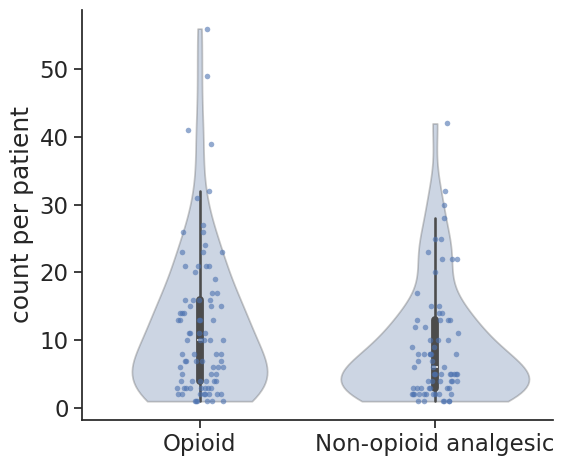

In [45]:
# Build a long-format dataframe for seaborn
plot_df = pd.DataFrame({
    'count': pd.concat([opioid_counts['opioid_count'], non_opioid_counts['non_opioid_count']], ignore_index=True),
    'type': ['Opioid'] * len(opioid_counts) + ['Non-opioid analgesic'] * len(non_opioid_counts)
})

sns.set_theme(style='white', font_scale=1.5)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=plot_df, x='type', y='count', ax=ax,
    cut=0,
    alpha=0.3,
)
sns.stripplot(
    data=plot_df, x='type', y='count', ax=ax,
    size=4,
    alpha=0.6,
    edgecolor='white',
    color = "C0",
    jitter=True,
)

ax.set_ylabel('count per patient')
ax.set_xlabel('')
sns.despine(ax=ax)
ax.tick_params(axis='y')

fig.tight_layout()
plt.savefig('analgesic_admin_distributions.png', bbox_inches='tight')
plt.show()



Unique medications: 295
                                         medication  count
0                      ACETAMINOPHEN 325 MG PO TABS    517
1                         SENNOSIDES 8.6 MG PO TABS    388
2          POLYETHYLENE GLYCOL 3350 17 GRAM PO PWPK    319
3                        LAMOTRIGINE 100 MG PO TABS    310
4       HYDROCODONE-ACETAMINOPHEN 10-325 MG PO TABS    290
5         CEFAZOLIN IV PUSH (1 GRAM VIAL + NS VIAL)    234
6        HYDROCODONE-ACETAMINOPHEN 5-325 MG PO TABS    201
7                            OXYCODONE 5 MG PO TABS    190
8                         LAMOTRIGINE 25 MG PO TABS    184
9                    DOCUSATE SODIUM 100 MG PO CAPS    175
10  DEXAMETHASONE SODIUM PHOSPHATE 4 MG/ML INJ SOLN    173
11          ONDANSETRON HCL (PF) 4 MG/2 ML INJ SOLN    147
12                       LORAZEPAM 2 MG/ML INJ SOLN    137
13                         FAMOTIDINE 20 MG PO TABS    130
14                     LEVETIRACETAM 500 MG PO TABS    128
15                     ACETAMINO

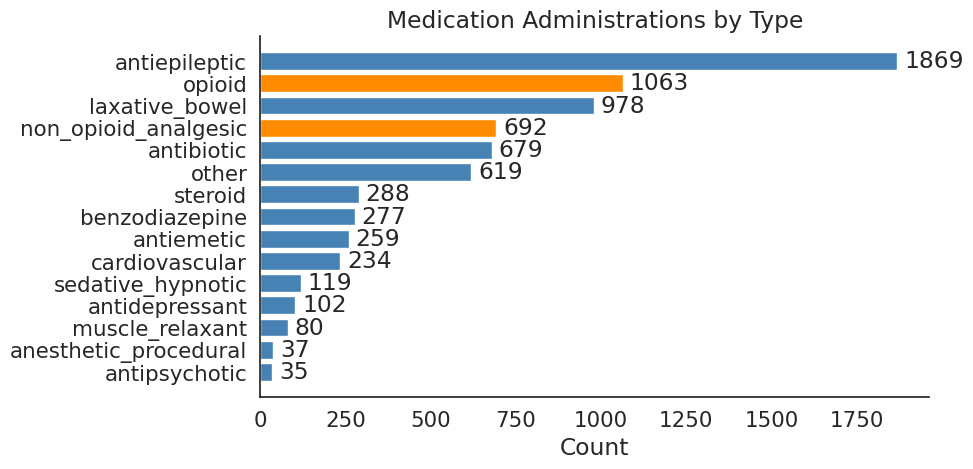

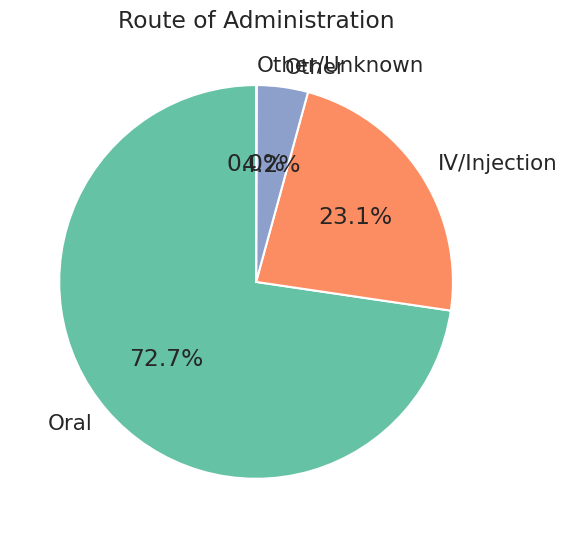

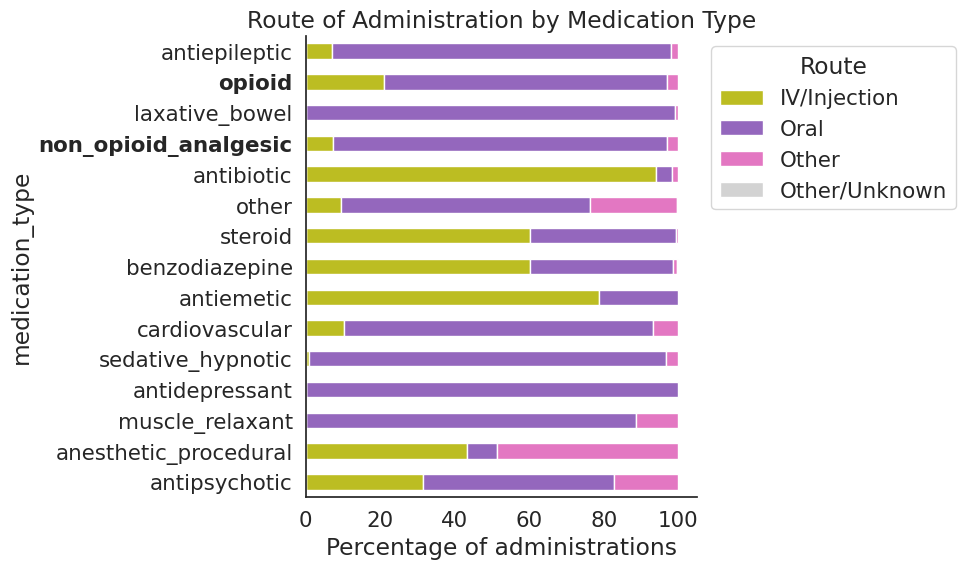

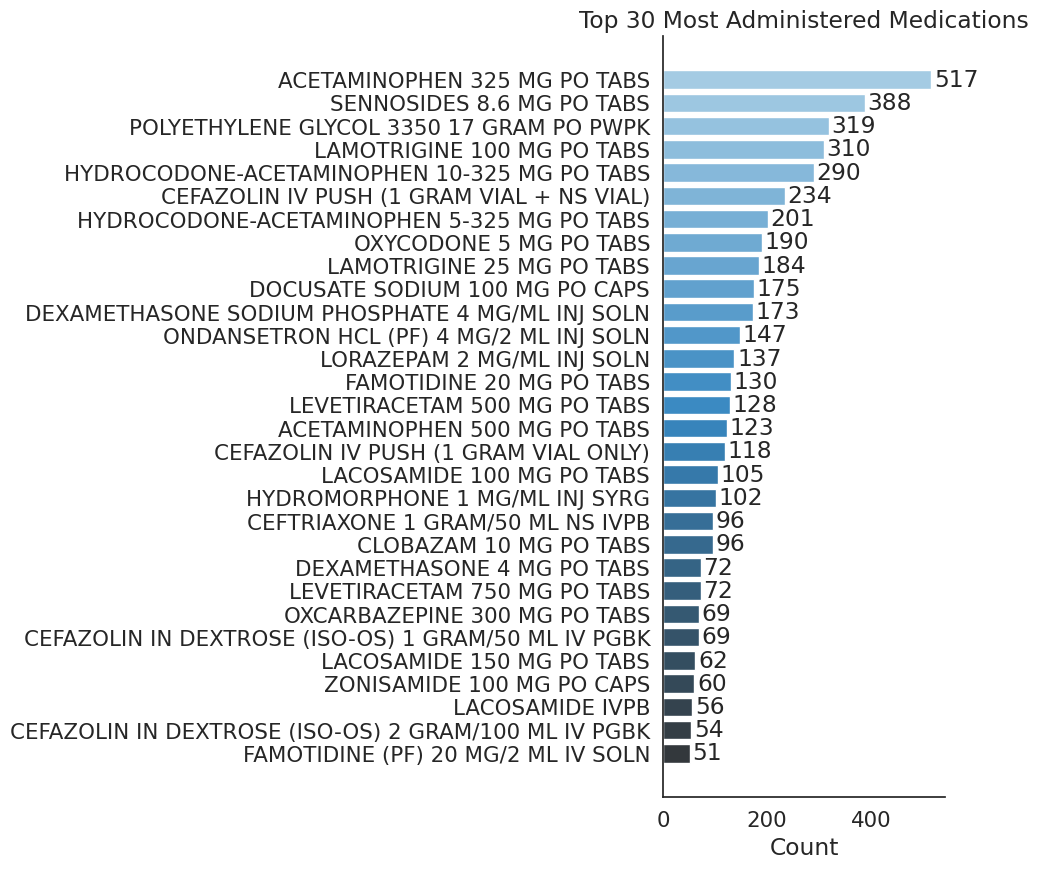

In [37]:
# %%
# Set global font size
sns.set_theme(style="white", font_scale=1.4)

# ── Medication counts ──────────────────────────────────────────────────────────

med_counts = med_admin_df['medication'].value_counts().reset_index()
med_counts.columns = ['medication', 'count']
print(f"Unique medications: {med_counts.shape[0]}")
print(med_counts.head(20))

type_counts = med_admin_df['medication_type'].value_counts().reset_index()
type_counts.columns = ['medication_type', 'count']
print("\nCounts by medication type:")
print(type_counts)

# %%
# ── Oral vs IV breakdown ───────────────────────────────────────────────────────

def classify_route(route):
    if pd.isna(route):
        return 'Other/Unknown'
    route = str(route).strip()
    if route == 'Oral':
        return 'Oral'
    elif route in ('Intravenous', 'Injection'):
        return 'IV/Injection'
    else:
        return 'Other'

med_admin_df['route_category'] = med_admin_df['route'].apply(classify_route)

route_counts = med_admin_df['route_category'].value_counts()
route_pct = (route_counts / route_counts.sum() * 100).round(1)

print("\nRoute breakdown:")
for r, n, p in zip(route_counts.index, route_counts.values, route_pct.values):
    print(f"  {r}: {n} ({p}%)")

# %%
# ── Figure 1: Medication type counts (bar chart) ───────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
highlight_types = {'opioid', 'non_opioid_analgesic'}
bar_colors = [
    'darkorange' if t in highlight_types else 'steelblue'
    for t in type_counts['medication_type']
]

bars = ax.barh(type_counts['medication_type'], type_counts['count'], color=bar_colors)

for bar, count in zip(bars, type_counts['count']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            str(count), va='center')

ax.set_xlabel("Count")
ax.set_title("Medication Administrations by Type")
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("med_type_counts.png", dpi=150)
plt.show()

# %%
# ── Figure 2: Oral vs IV pie chart ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
wedge_colors = sns.color_palette("Set2", len(route_counts))
ax.pie(
    route_counts.values,
    labels=route_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
ax.set_title("Route of Administration")
plt.tight_layout()
plt.savefig("route_pie.png", dpi=150)
plt.show()

# %%
# ── Figure 3: Route breakdown within each medication type ─────────────────────

# ── Figure 3: Route breakdown within each medication type ─────────────────────

# Match order from Figure 1 (sorted by count descending)
ordered_types = type_counts['medication_type'].tolist()

route_by_type = (
    med_admin_df
    .groupby(['medication_type', 'route_category'])
    .size()
    .unstack(fill_value=0)
)
route_by_type_pct = route_by_type.div(route_by_type.sum(axis=1), axis=0) * 100

# Reindex to match Figure 1 order (invert since we'll invert y-axis)
route_by_type_pct = route_by_type_pct.reindex(ordered_types)

# Colors: avoid orange and blue
route_color_map = {
    'IV/Injection':  'tab:olive',   # green
    'Oral':          'tab:purple',   # purple
    'Other':         'tab:pink',   # red
    'Other/Unknown': 'lightgrey',   # grey
}
cols_present = [c for c in route_color_map if c in route_by_type_pct.columns]
plot_colors = [route_color_map[c] for c in cols_present]

fig, ax = plt.subplots(figsize=(10, 6))
route_by_type_pct[cols_present].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=plot_colors,
    edgecolor='white'
)

ax.set_xlabel("Percentage of administrations")
ax.set_title("Route of Administration by Medication Type")
ax.legend(title="Route", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.invert_yaxis()
sns.despine()

# Bold opioid and non-opioid analgesic y-tick labels
highlight = {'opioid', 'non_opioid_analgesic'}
for label in ax.get_yticklabels():
    if label.get_text() in highlight:
        label.set_fontweight('bold')

plt.tight_layout()
plt.savefig("route_by_med_type.png", dpi=150)
plt.show()

# %%
# ── Figure 4: Top N individual medications ────────────────────────────────────

TOP_N = 30
top_meds = med_counts.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top_meds['medication'], top_meds['count'],
               color=sns.color_palette("Blues_d", TOP_N))
for bar, count in zip(bars, top_meds['count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(count), va='center')

ax.set_xlabel("Count")
ax.set_title(f"Top {TOP_N} Most Administered Medications")
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("top_meds.png", dpi=150)
plt.show()

Opioid administration counts:
       opioid  count  pct
  Hydrocodone    493 46.4
    Oxycodone    225 21.2
Hydromorphone    157 14.8
     Fentanyl     95  8.9
     Tramadol     39  3.7
     Morphine     25  2.4
Buprenorphine     15  1.4
      Codeine     14  1.3


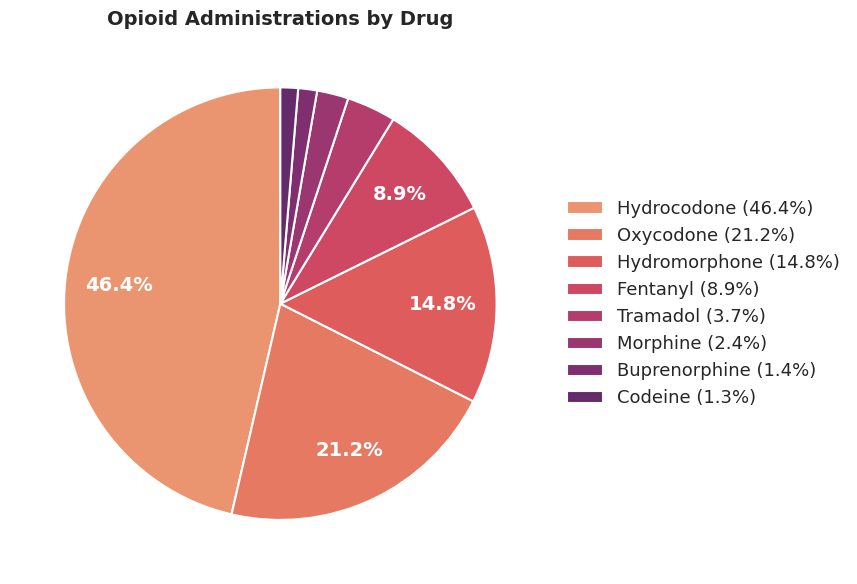

In [ ]:
# %%
# ── Opioid breakdown by drug name (collapsed across doses) ────────────────────

# Drug name extraction map for opioids
opioid_name_map = {
    'OXYCODONE': 'Oxycodone',
    'HYDROMORPHONE': 'Hydromorphone',
    'FENTANYL': 'Fentanyl',
    'MORPHINE': 'Morphine',
    'TRAMADOL': 'Tramadol',
    'HYDROCODONE': 'Hydrocodone',          # includes hydrocodone-acetaminophen combos
    'OXYCODONE-ACETAMINOPHEN': 'Oxycodone', # collapses into oxycodone
    'ACETAMINOPHEN-CODEINE': 'Codeine',
    'BUPRENORPHINE': 'Buprenorphine',
}

def extract_opioid_name(med_name):
    """Return canonical opioid name, ignoring dose/formulation."""
    med_upper = str(med_name).upper()
    # Check hydrocodone-acetaminophen before plain hydrocodone
    if 'HYDROCODONE' in med_upper:
        return 'Hydrocodone'
    if 'OXYCODONE-ACETAMINOPHEN' in med_upper:
        return 'Oxycodone'
    if 'OXYCODONE' in med_upper:
        return 'Oxycodone'
    if 'FENTANYL' in med_upper:
        return 'Fentanyl'
    if 'HYDROMORPHONE' in med_upper:
        return 'Hydromorphone'
    if 'MORPHINE' in med_upper:
        return 'Morphine'
    if 'TRAMADOL' in med_upper:
        return 'Tramadol'
    if 'CODEINE' in med_upper:
        return 'Codeine'
    if 'BUPRENORPHINE' in med_upper:
        return 'Buprenorphine'
    return 'Other Opioid'

# Filter to opioids only and extract drug name
opioid_df = med_admin_df[med_admin_df['medication_type'] == 'opioid'].copy()
opioid_df['opioid_name'] = opioid_df['medication'].apply(extract_opioid_name)

opioid_counts = opioid_df['opioid_name'].value_counts().reset_index()
opioid_counts.columns = ['opioid', 'count']
opioid_counts['pct'] = (opioid_counts['count'] / opioid_counts['count'].sum() * 100).round(1)

print("Opioid administration counts:")
print(opioid_counts.to_string(index=False))

# %%


# ── Figure: Opioid breakdown — pie only ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6))

colors = sns.color_palette("flare", len(opioid_counts))

wedges, texts, autotexts = ax.pie(
    opioid_counts['count'],
    autopct=lambda p: f'{p:.1f}%' if p >= 4 else '',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')

ax.legend(
    wedges,
    [f"{row.opioid} ({row.pct}%)" for row in opioid_counts.itertuples()],
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=13,
    title_fontsize=15,
    frameon=False,
)

ax.set_title(
    "Opioid Administrations by Drug",
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig("opioid_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style
sns.set_theme(style="white")

# %%
# Configuration
BIDS_DIR = Path('/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB')

# %%
# Find all pain score CSV files
print("Searching for diagnoses files...")
pain_files = list(BIDS_DIR.glob('sub-*/ses-*/ehr/*_diagnoses.csv'))

# %%
# Load all pain data — fixed datetime parsing
all_pain_data = []
for file in pain_files:
    df = pd.read_csv(file)
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')
    df['session_start'] = pd.to_datetime(df['session_start'], format='%Y-%m-%d %H:%M:%S')
    df['session_end'] = pd.to_datetime(df['session_end'], format='%Y-%m-%d %H:%M:%S')
    all_pain_data.append(df)

diagnosis_df = pd.concat(all_pain_data, ignore_index=True)



print(f"\nLoaded {len(diagnosis_df)} total pain measurements")
print(f"Participants: {diagnosis_df['sub_id'].nunique()}")
print(f"Sessions: {len(diagnosis_df.groupby(['sub_id', 'ses_id']))}")
diagnosis_df


Searching for diagnoses files...

Loaded 65941 total pain measurements
Participants: 99
Sessions: 101


,sub_id,ses_id,session_start,session_end,date,type,source,icd9_code,icd10_code,description,performing_provider,billing_provider
0,sub-231,ses-01,2000-01-01 15:33:47,2000-01-15 14:17:18,1996-08-22 00:00:00,Primary,Professional Billing Code,NaN,R94.31,Abnormal electrocardiogram (ECG) (EKG),CP0040867 - CARDIOVASCULAR MEDICINE,CP0040867 - CARDIOVASCULAR MEDICINE
1,sub-231,ses-01,2000-01-01 15:33:47,2000-01-15 14:17:18,1996-08-22 00:00:00,NaN,Encounter Diagnosis,300.00,F41.9,Anxiety,CP0286104 - NEUROLOGY,NaN
2,sub-231,ses-01,2000-01-01 15:33:47,2000-01-15 14:17:18,1996-08-22 00:00:00,NaN,Professional Billing Code,NaN,F41.9,"Anxiety disorder, unspecified",CP0286104 - NEUROLOGY,CP0286104 - NEUROLOGY
3,sub-231,ses-01,2000-01-01 15:33:47,2000-01-15 14:17:18,1996-08-22 00:00:00,Primary,Encounter Diagnosis,345.50,G40.109,Focal epilepsy (CMS-HCC),CP0286104 - NEUROLOGY,NaN
4,sub-231,ses-01,2000-01-01 15:33:47,2000-01-15 14:17:18,1996-08-22 00:00:00,NaN,Encounter Diagnosis,345.50,G40.109,Focal epilepsy (CMS-HCC),C3000011 - LAB,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
65936,sub-256,ses-01,2000-01-01 20:30:14,2000-01-11 16:21:18,2000-03-21 11:00:00,NaN,Admit Diagnosis,NaN,F44.5,Conversion disorder with seizures or convulsions,NaN,NaN
65937,sub-256,ses-01,2000-01-01 20:30:14,2000-01-11 16:21:18,2000-03-21 11:00:00,NaN,Admit Diagnosis,NaN,R56.9,Unspecified convulsions,NaN,NaN
65938,sub-256,ses-01,2000-01-01 20:30:14,2000-01-11 16:21:18,2000-03-21 11:00:00,NaN,Professional Billing Code,NaN,R56.9,Unspecified convulsions,NaN,NaN
65939,sub-256,ses-01,2000-01-01 20:30:14,2000-01-11 16:21:18,2000-04-08 00:00:00,Primary,Encounter Diagnosis,780.39,R56.9,Focal seizure (CMS-HCC),CP0369433 - REGISTERED NURSE,NaN


In [55]:
diagnosis_df = diagnosis_df[diagnosis_df['source'].isin(['Encounter Diagnosis', 'Admit Diagnosis'])]
unique_icd10 = diagnosis_df['icd10_code'].unique()

has_mdd        25
has_gad         2
has_bipolar     1
healthy        74
dtype: int64
Total sessions: 101


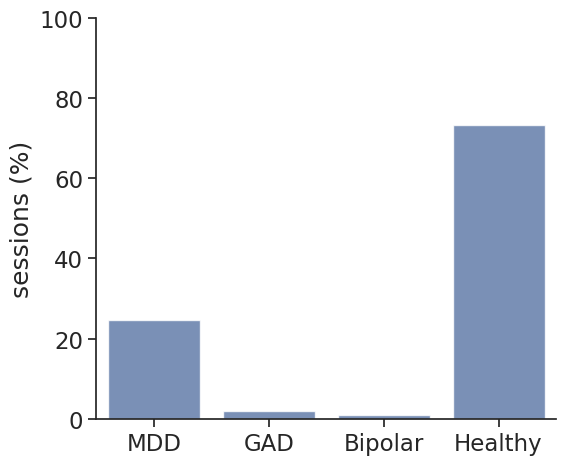

     sub_id  ses_id                date       session_start
1   sub-231  ses-01 1996-08-22 00:00:00 2000-01-01 15:33:47
3   sub-231  ses-01 1996-08-22 00:00:00 2000-01-01 15:33:47
4   sub-231  ses-01 1996-08-22 00:00:00 2000-01-01 15:33:47
6   sub-231  ses-01 1996-08-22 12:22:00 2000-01-01 15:33:47
8   sub-231  ses-01 1996-08-22 12:22:00 2000-01-01 15:33:47
10  sub-231  ses-01 1996-08-22 14:38:00 2000-01-01 15:33:47
12  sub-231  ses-01 1996-08-22 14:38:00 2000-01-01 15:33:47
17  sub-231  ses-01 1996-09-25 14:26:00 2000-01-01 15:33:47
20  sub-231  ses-01 1996-10-09 15:46:00 2000-01-01 15:33:47
22  sub-231  ses-01 1996-10-09 15:46:00 2000-01-01 15:33:47

date dtype: datetime64[ns]
session_start dtype: datetime64[ns]

days_before range: -4884 to 5526
NaT count in days_before: 0

Rows before window filter: 28309
Rows after window filter: 4955

MDD codes found in full diag_df (no window):
        sub_id  ses_id icd10_code                date       session_start  \
2118   sub-127  ses-01    

In [9]:
# Ensure datetime

# Define code lists
mdd_codes = [
    'F32.A', 'F32.1', 'F32.4', 'F32.9', 'F32.89',
    'F33.1', 'F33.2', 'F33.3', 'F33.9', 'F33.41',
    'F06.31', 'F06.30', 'F06.34',
]
gad_codes = ['F41.1']
bipolar_codes = ['F31.0', 'F31.1', 'F31.2', 'F31.3', 'F31.4', 
                 'F31.5', 'F31.6', 'F31.7', 'F31.8', 'F31.9',
                 'F31.10', 'F31.11', 'F31.12', 'F31.13',
                 'F31.30', 'F31.31', 'F31.32',
                 'F31.60', 'F31.61', 'F31.62', 'F31.63', 'F31.64',
                 'F31.70', 'F31.71', 'F31.72', 'F31.73', 'F31.74', 'F31.75',
                 'F31.76', 'F31.77', 'F31.78']

diag_df = diagnosis_df[diagnosis_df['source'].isin(['Encounter Diagnosis', 'Admit Diagnosis'])].copy()
diag_df['date'] = pd.to_datetime(diag_df['date'])
diag_df['session_start'] = pd.to_datetime(diag_df['session_start'])

# For each row, check if diagnosis is within 1 year before session_start
diag_df['days_before'] = (diag_df['session_start'] - diag_df['date']).dt.days
diag_df_window = diag_df[(diag_df['days_before'] >= 0) & (diag_df['days_before'] <= 365)]

# Flag each row by diagnosis category
diag_df_window = diag_df_window.copy()
diag_df_window['has_mdd']     = diag_df_window['icd10_code'].isin(mdd_codes)
diag_df_window['has_gad']     = diag_df_window['icd10_code'].isin(gad_codes)
diag_df_window['has_bipolar'] = diag_df_window['icd10_code'].isin(bipolar_codes)

# Collapse to one row per sub_id/ses_id — True if any row in that session has the diagnosis
session_dx = diag_df_window.groupby(['sub_id', 'ses_id'])[['has_mdd', 'has_gad', 'has_bipolar']].any().reset_index()

# Get all unique sub_id/ses_id combinations from the full ehr_df
all_sessions = diagnosis_df[['sub_id', 'ses_id']].drop_duplicates()

# Left join so sessions with no matching diagnosis rows get False
session_dx = all_sessions.merge(session_dx, on=['sub_id', 'ses_id'], how='left').fillna(False)

# Sessions with none of the diagnoses = healthy
session_dx['healthy'] = ~(session_dx['has_mdd'] | session_dx['has_gad'] | session_dx['has_bipolar'])

# Count unique sub_id/ses_id combinations per category
n_total = len(session_dx)
plot_df = pd.DataFrame({
    'diagnosis': ['MDD', 'GAD', 'Bipolar', 'Healthy'],
    'percent': [
        session_dx['has_mdd'].mean() * 100,
        session_dx['has_gad'].mean() * 100,
        session_dx['has_bipolar'].mean() * 100,
        session_dx['healthy'].mean() * 100,
    ]
})

print(session_dx[['has_mdd','has_gad','has_bipolar','healthy']].sum())
print(f"Total sessions: {n_total}")

# Plot
sns.set_theme(style='white', font_scale=1.5)
sns.set_style('ticks')

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=plot_df, x='diagnosis', y='percent', color='C0', alpha=0.8, ax=ax)
ax.set_ylabel('subjects (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)
sns.despine(ax=ax)
fig.tight_layout()
plt.savefig('diagnosis_prevalence.png', bbox_inches='tight')
plt.show()


# Step 1: check what the date columns look like before filtering
print(diag_df[['sub_id', 'ses_id', 'date', 'session_start']].head(10))
print("\ndate dtype:", diag_df['date'].dtype)
print("session_start dtype:", diag_df['session_start'].dtype)

# Step 2: check if days_before is computing sensibly
diag_df['days_before'] = (diag_df['session_start'] - diag_df['date']).dt.days
print("\ndays_before range:", diag_df['days_before'].min(), "to", diag_df['days_before'].max())
print("NaT count in days_before:", diag_df['days_before'].isna().sum())

# Step 3: check how many rows survive the window filter
print("\nRows before window filter:", len(diag_df))
print("Rows after window filter:", len(diag_df_window))

# Step 4: check if any MDD codes are actually present in diag_df at all, ignoring the window
print("\nMDD codes found in full diag_df (no window):")
print(diag_df[diag_df['icd10_code'].isin(mdd_codes)][['sub_id', 'ses_id', 'icd10_code', 'date', 'session_start', 'days_before']])

group
Healthy           65
Active MDD        24
History of MDD    12
Name: count, dtype: int64
Total sessions: 101


/tmp/ipykernel_12269/2486513388.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Healthy', 'Active\nMDD', 'History of\nMDD'])


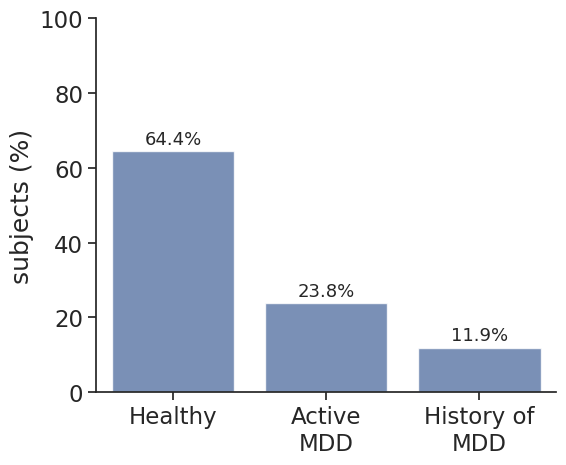

In [13]:
active_mdd_codes = [
    'F32.A', 'F32.1', 'F32.9', 'F32.89',
    'F33.1', 'F33.2', 'F33.3', 'F33.9',
    'F06.31', 'F06.30', 'F06.34',
]
history_mdd_codes = [
    'F32.4',   # single episode, partial remission
    'F33.41',  # recurrent, partial remission
    'F33.40',  # recurrent, in remission
    'Z86.16',  # personal history of depression
]

# Start from the full ehr_df filtered to diagnosis rows
diag_df = diagnosis_df[diagnosis_df['source'].isin(['Encounter Diagnosis', 'Admit Diagnosis'])].copy()  # adjust to your actual source values
diag_df['date'] = pd.to_datetime(diag_df['date'])
diag_df['session_start'] = pd.to_datetime(diag_df['session_start'])

# Only keep rows where diagnosis date is before session_start
diag_df = diag_df[diag_df['date'] <= diag_df['session_start']].copy()
diag_df['days_before'] = (diag_df['session_start'] - diag_df['date']).dt.days

# Flag active MDD: active code within 1 year
diag_df['is_active_mdd'] = (
    diag_df['icd10_code'].isin(active_mdd_codes) &
    (diag_df['days_before'] <= 365)
)

# Flag history MDD: active code more than 1 year ago, OR remission/history code at any time
diag_df['is_history_mdd'] = (
    (diag_df['icd10_code'].isin(active_mdd_codes) & (diag_df['days_before'] > 365)) |
    (diag_df['icd10_code'].isin(history_mdd_codes))
)

# Collapse to session level
session_dx = diag_df.groupby(['sub_id', 'ses_id'])[['is_active_mdd', 'is_history_mdd']].any().reset_index()

# Left join to all sessions so sessions with no diagnoses are included
all_sessions = diagnosis_df[['sub_id', 'ses_id']].drop_duplicates()
session_dx = all_sessions.merge(session_dx, on=['sub_id', 'ses_id'], how='left')
session_dx[['is_active_mdd', 'is_history_mdd']] = session_dx[['is_active_mdd', 'is_history_mdd']].fillna(False).infer_objects(copy=False)

# Apply priority ordering: Active MDD > History > Healthy
def assign_group(row):
    if row['is_active_mdd']:
        return 'Active MDD'
    elif row['is_history_mdd']:
        return 'History of MDD'
    else:
        return 'Healthy'

session_dx['group'] = session_dx.apply(assign_group, axis=1)

# Compute percentages
n_total = len(session_dx)
plot_df = (
    session_dx['group']
    .value_counts()
    .reindex(['Healthy', 'History of MDD', 'Active MDD'])
    .reset_index()
)
plot_df.columns = ['group', 'count']
plot_df['percent'] = plot_df['count'] / n_total * 100

print(session_dx['group'].value_counts())
print(f"Total sessions: {n_total}")

# Plot
sns.set_theme(style='white', font_scale=1.5)
sns.set_style('ticks')
# Reorder so Active MDD comes before History
plot_df = (
    session_dx['group']
    .value_counts()
    .reindex(['Healthy', 'Active MDD', 'History of MDD'])  # swapped order
    .reset_index()
)
plot_df.columns = ['group', 'count']
plot_df['percent'] = plot_df['count'] / n_total * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=plot_df, x='group', y='percent', color='C0', alpha=0.8, ax=ax)

# Add percentage labels on top of each bar
for i, row in plot_df.iterrows():
    ax.text(i, row['percent'] + 1, f"{row['percent']:.1f}%",
            ha='center', va='bottom', fontsize=13)

ax.set_ylabel('subjects (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)

# Fix x-tick labels to wrap long text
ax.set_xticklabels(['Healthy', 'Active\nMDD', 'History of\nMDD'])

sns.despine(ax=ax)
fig.tight_layout()
plt.savefig('mdd_prevalence.png', bbox_inches='tight', dpi=300)
plt.show()